In [46]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [48]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6


In [49]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [50]:
EX = N_EX / gamma
EY = N_EY / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [51]:
deltaP_P = 1.5e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.0015


In [52]:
from elements import TECA
from elements import TECS


# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle 

In [53]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),# Desired target tunes
            #xt.TargetSet(dqx=-1 * qx, dqy=0.47 * qy, tol=1e-3),   # Desired target chromaticities
        ])
    return opt

In [54]:
def match_chromaticity(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['klsfa', 'klsda', 'klsdb', 'klsfb'], step=1e-7),   # Varying setupoles strengths ,  klsfa, klsda, klsfb, klsdb????
        ],
        targets=[
            xt.TargetSet(dqx=-1 * int(qx), dqy = 0.47 * int(qy), tol=1e-3),   # Desired target chromaticities
        ])
    return opt

# Importing the line

In [55]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']

line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 4890766800>

In [56]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

tw0 = tw_init.to_pandas()
tw0.index = tw0.name  

betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) * 1e3
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2) * 1e3
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} mm")
print(f"sigma_y max = {tw0.sy_mm.max()} mm")

# DISPERSION AND BETX AT THE TECA LOCATION
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) 
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2)
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

sigma_xMAXQ22 = tw0.sx_mm.max()
sigma_yMAXQ22 = tw0.sy_mm.max()


print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} m")
print(f"sigma_y max = {tw0.sy_mm.max()} m")

mu_x_teca = tw0.loc['TECA.entry'].mux
mu_x_tpst = tw0.loc['tpst.21760_entry'].mux
mu_x_tcsm = tw0.loc['tcsm.51932.'].mux

phaseAdvanceTecaTpst = mu_x_tpst - mu_x_teca
phaseAdvanceTecaTcsm = mu_x_tcsm - mu_x_teca
phaseAdvanceTpstTcsm = mu_x_tcsm - mu_x_tpst

print(f"Phase advance Teca - Tpst: {phaseAdvanceTecaTpst:.2f}")
print(f"Phase advance Teca - Tcsm: {phaseAdvanceTecaTcsm:.2f}")
print(f"Phase advance Tpst - Tcsm: {phaseAdvanceTpstTcsm:.2f}")

22.13000000010263
22.180000000010537
D term / B term = 3.31
sigma_x max = 10.468444863433009 mm
sigma_y max = 1.1036200168346404 mm
D term / B term = 3.31
sigma_x max = 0.010468444863433008 m
sigma_y max = 0.0011036200168346405 m
Phase advance Teca - Tpst: 14.74
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: -10.91


In [57]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']


In [58]:
tune = 22.99

In [59]:
optTune = match_tunes(line, tune, tune + 0.05)
optChromaticity = match_chromaticity(line, tune, tune + 0.05)

optTune.step(10)
optTune.target_status()
optTune.vary_status()

# CHanging the chromaticity afterwards
optChromaticity.step(10)

optChromaticity.target_status()
optChromaticity.vary_status() 

# Save the line with the current optics into a JSON file
line.to_json("../database/lhc_q23.json")

line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)

                                             
Optimize - start penalty: 12.16         
Matching: model call n. 19               
Optimize - end penalty:  8.64399e-07
Target status:                           
id state tag tol_met       residue   current_val    target_val description                          
0  ON    qx     True   8.64312e-08         22.99         22.99 'qx', val=22.99, tol=1e-05, weight=10
1  ON    qy     True   1.22955e-09         23.04         23.04 'qy', val=23.04, tol=1e-05, weight=10
Vary status:                 
id state tag met name         lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqf          None            0.0129904 None            0.0125751         1e-07             1
1  ON        OK  kqd          None           -0.0129933 None           -0.0125777         1e-07             1
2  ON        OK  qph_setvalue None          4.27426e-14 None                    0        0.0001             1
3  ON        OK  qp

Moving the TPST blade

In [60]:
element_name = 'tpst.21760_entry.sep'
element = line[element_name]

print(f"Element Name: {element_name}")
print(f"Type: {type(element)}")
print(f"Length: {element.length}")
print(f"Blade Position: {element.interaction_process.blade_position}")
print(f"Thickness: {element.interaction_process.thickness}")
print(f"Kick: {element.interaction_process.kick}")


# MOVING THE BLADE UP OR DOWN
element.interaction_process.blade_position = 0.03
print(f"Updated Blade Position: {element.interaction_process.blade_position}")

Element Name: tpst.21760_entry.sep
Type: <class 'xdeps.madxutils.View'>
Length: 0.0
Blade Position: 0.04
Thickness: 0.01
Kick: 0
Updated Blade Position: 0.03


Checking if the particles can go through the line without getting blocked by an aperture

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Slicing line:   0%|          | 0/4614 [00:00<?, ?it/s]

Particle lost at turn 0


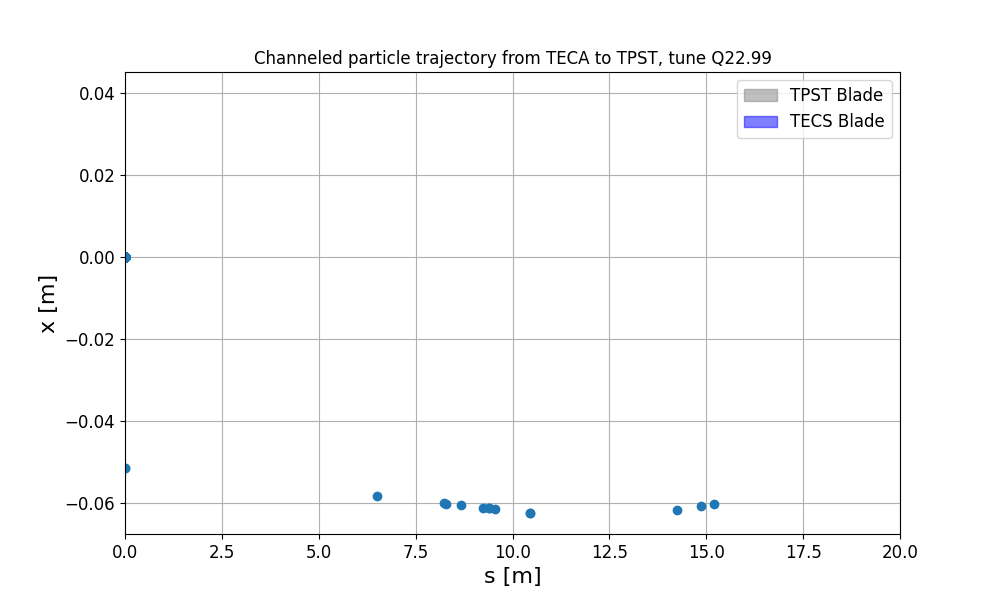

In [61]:
tw = line.twiss(method='4d')

line.discard_tracker()
line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )
line.build_tracker()

# Initialize a single particle at TECA location
particles = line.build_particles(
        method='4d',
        x = TECA.jaw,
        px = TECA.tilt + TECA.bending_angle,                    # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
        y = 0,
        py = 0,
        zeta = 0,
        delta = deltaP_P,
        mass0 = xt.PROTON_MASS_EV,
        p0c = 400e9
    )

# Track particles for N turns and store positions
num_turns = 1
line.track(
        particles,
        num_turns=num_turns,
        turn_by_turn_monitor="ONE_TURN_EBE",
    )
    

    # Check if the particle is lost during the tracking
if np.any(particles.state < 1):
    lost_turn = np.where(particles.state < 1)[0][0]
    print(f"Particle lost at turn {lost_turn}")
else:
    print("Particle not lost during the tracking")
    
    
# Plot the phase space at TECA location
plt.figure(figsize=(10, 6))
#plt.plot(line.record_last_track.x, line.record_last_track.px, 'o')
plt.plot(line.record_last_track.s[0], line.record_last_track.x[0], 'o')

#plt.xlabel('x [m]')
plt.xlabel('s [m]')

#plt.ylabel('px [rad]')
plt.ylabel('x [m]')

plt.title(f'Channeled particle trajectory from TECA to TPST, tune Q{tune}')
plt.grid(True)

# Draw a rectangle at the TPST entry location
tpst = plt.Rectangle((tpst_position, element.interaction_process.blade_position), 
                     width=2, height=element.interaction_process.thickness, 
                     color='grey', alpha=0.5, label='TPST Blade')
plt.gca().add_patch(tpst)

tecs_position = line.get_table()['s', 'TECS.everest_crystal']
tecs = plt.Rectangle((tecs_position, TECS.jaw), 
                     width=TECA.length, height=TECA.width, 
                     color='blue', alpha=0.5, label='TECS Blade')
plt.gca().add_patch(tecs)

#plt.ylim(-1, 1)
plt.xlim(0, 20)
#plt.ylim(-0.1, 0.1)
#plt.xlim(4520, 4620)

#plt.axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
#plt.axvline(x=tecs_position, color='r', linestyle='--', label='TECS location')


plt.legend()

The particle is lost due to an interaction with an element. Let's find this element:

In [62]:
# Check if the particle is lost during the tracking
if np.any(particles.state < 1):
    lost_turn = np.where(particles.state < 1)[0][0]
    lost_element_index = particles.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
else:
    print("Particle not lost during the tracking")
    
# Print the x position of the particle at the element where it gets lost
x_position_at_loss = particles.x[lost_turn]
print(f"Particle x position at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}: {x_position_at_loss}")
# Print the aperture of the element where the particle gets lost
element_aperture = line[lost_element_name].max_x
print(f"Aperture of element {lost_element_name} (index {lost_element_index}): {element_aperture}")

# Compare the x position of the particle with the aperture
if abs(x_position_at_loss) > element_aperture:
    print(f"Particle x position {x_position_at_loss} exceeds the aperture {element_aperture} of element {lost_element_name}")
else:
    print(f"Particle x position {x_position_at_loss} is within the aperture {element_aperture} of element {lost_element_name}")

Particle lost at element ap.up.tpsg41832_aper (index 14) on turn 0
Particle x position at element ap.up.tpsg41832_aper (index 14) on turn 0: -0.06024356850326222
Aperture of element ap.up.tpsg41832_aper (index 14): 0.049
Particle x position -0.06024356850326222 exceeds the aperture 0.049 of element ap.up.tpsg41832_aper


Let's find all the original apertures in order to plot them in the

In [63]:
import pandas as pd

# Initialize lists to store the data
element_names = []
max_x_values = []
min_x_values = []
positions = []

# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    if hasattr(element, 'max_x') and hasattr(element, 'min_x'):
        element_names.append(element_name)
        max_x_values.append(element.max_x)
        min_x_values.append(element.min_x)
        positions.append(line.get_table()['s', element_name])
    elif isinstance(element, xt.LimitEllipse):
        element_names.append(element_name)
        max_x_values.append(element.a)
        min_x_values.append(-element.a)
        positions.append(line.get_table()['s', element_name])

# Create a DataFrame
df_elements = pd.DataFrame({
    'Position': positions,
    'Element Name': element_names,
    'max_x': max_x_values,
    'min_x': min_x_values
})

# Display the DataFrame
print(df_elements)


      Position         Element Name    max_x    min_x
0    3336.5340        qe.11402_aper  0.07600 -0.07600
1    3434.5709        qd.11710_aper  0.04150 -0.04150
2    3438.9739      mdhw.11732_aper  0.07600 -0.07600
3    3442.7352      mdhw.11737_aper  0.07600 -0.07600
4    3443.7942      mdhw.11738_aper  0.07600 -0.07600
..         ...                  ...      ...      ...
103  2329.0933  ap.up.mse61857_aper  0.06850 -0.06850
104  2331.4733  ap.do.mse61857_aper  0.07635 -0.07635
105  2332.3273  ap.up.mse61872_aper  0.08024 -0.08024
106  2334.7073  ap.do.mse61872_aper  0.09100 -0.09100
107  4638.5419      tt20.extraction  0.07000 -1.00000

[108 rows x 4 columns]


# Uploading the line with the desired optics

In [64]:
line = xt.Line.from_json("../database/lhc_q23.json")   # This optics if for the tune Q22.99

# Set reference particle
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# Install septa and cycle the line
#septa_names_with_apertures = install_septa(line, install_zs=False)
line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4606 [00:00<?, ?it/s]

Done loading line from dict.           


<Line  at 4940065488>

## Looking for the apertures that block the particle

Doing two different loops doing the same thing, one for the channeled particles and one for the non-channeled particles

In [65]:
import numpy as np
import xtrack as xt
from elements import install_septa

# Storage for elements blocking the particle
blocking_elements = []

while True:
    # Build tracker
    line.build_tracker()

    # Initialize non-channeled particle at TECA location
    particlesNONCH = line.build_particles(
        method='4d',
        x = TECA.jaw,  # Start with 0 offset
        px = TECA.tilt,  # Start with 0 offset
        y=0.0,
        py=0.0,
        zeta=0.0,
        delta = deltaP_P,
        mass0=xt.PROTON_MASS_EV,
        p0c=400e9
    )

    # Track the particle
    line.track(particlesNONCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE")

    # Check if the particle reached the end
    if particlesNONCH.state[0] >= 1 and particlesNONCH.at_element[0] == line.get_table()['name', '_end_point']:
        print("Particle successfully reached the end.")
        break  # Exit loop

    if np.any(particlesNONCH.state < 1):
        lost_turn = np.where(particlesNONCH.state < 1)[0][0]
        lost_element_index = particlesNONCH.at_element[lost_turn]
        lost_element_name = line.element_names[lost_element_index]
        print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
        # Store blocking element details
        blocking_elements.append((lost_element_name, particlesNONCH.x[lost_turn]))
        element = line[lost_element_name]
        if isinstance(element, xt.LimitEllipse):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.a *= 1.5  # Increase the semi-major axis by 50%
            element.b *= 1.5  # Increase the semi-minor axis by 50%
        elif hasattr(element, 'min_x') and hasattr(element, 'max_x'):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.min_x *= 1.5  # Increase the minimum x aperture by 50%
            element.max_x *= 1.5  # Increase the maximum x aperture by 50%
        else:
            print(f"Element {lost_element_name} does not have adjustable apertures.")
        
        
    else:
        print("Particle not lost during the tracking")
        break
    # line.discard_tracker()
    # Increase aperture of the blocking element
    #if hasattr(line[lost_element_name], 'max_x'):
    #    line[lost_element_name].max_x = abs(x_position_at_loss) + 1e-3  # Slightly increase aperture

# Print results
print("Blocking elements encountered:")
for elem, x_pos in blocking_elements:
    print(f"Element: {elem}, X position: {x_pos}")


Particle lost at element ap.up.tpsg41832_aper (index 14) on turn 0
Element Name: ap.up.tpsg41832_aper, Element: View of LimitRect(min_x=-0.049, max_x=0.049, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.do.tpsg41832_aper (index 17) on turn 0
Element Name: ap.do.tpsg41832_aper, Element: View of LimitRect(min_x=-0.0464, max_x=0.0464, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.up.mse41837_aper (index 20) on turn 0
Element Name: ap.up.mse41837_aper, Element: View of LimitRect(min_x=-0.0469, max_x=0.0469, min_y=-0.078, max_y=0.078, _sin_rot_s=-999, _cos_rot_s=-999, _shift_x=0, _shift_y=0, _shift_s=0)
The line already has an associated tracker
Particle lost at element ap.do.mse41837_aper (index 25) on turn 0
Element Name: ap.do.mse41837_aper, Elemen

In [66]:
import numpy as np
import xtrack as xt
from elements import install_septa

# Storage for elements blocking the particle

while True:
    # Build tracker
    line.build_tracker()

    # Initialize non-channeled particle at TECA location
    particlesCH = line.build_particles(
        method='4d',
        x = TECA.jaw,  # Start with 0 offset
        px = TECA.tilt + TECA.bending_angle,  # Start with 0 offset
        y=0.0,
        py=0.0,
        zeta=0.0,
        delta = deltaP_P,
        mass0=xt.PROTON_MASS_EV,
        p0c=400e9
    )

    # Track the particle
    line.track(particlesCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE")

    # Check if the particle reached the end
    if particlesCH.state[0] >= 1 and particlesCH.at_element[0] == line.get_table()['name', '_end_point']:
        print("Particle successfully reached the end.")
        break  # Exit loop

    if np.any(particlesCH.state < 1):
        lost_turn = np.where(particlesCH.state < 1)[0][0]
        lost_element_index = particlesCH.at_element[lost_turn]
        lost_element_name = line.element_names[lost_element_index]
        print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
        # Store blocking element details
        blocking_elements.append((lost_element_name, particlesCH.x[lost_turn]))
        element = line[lost_element_name]
        if isinstance(element, xt.LimitEllipse):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.a *= 1.5  # Increase the semi-major axis by 50%
            element.b *= 1.5  # Increase the semi-minor axis by 50%
        elif hasattr(element, 'min_x') and hasattr(element, 'max_x'):
            print(f"Element Name: {lost_element_name}, Element: {element}")
            element.min_x *= 1.5  # Increase the minimum x aperture by 50%
            element.max_x *= 1.5  # Increase the maximum x aperture by 50%
        else:
            print(f"Element {lost_element_name} does not have adjustable apertures.")
        
        
    else:
        print("Particle not lost during the tracking")
        break
    # line.discard_tracker()
    # Increase aperture of the blocking element
    #if hasattr(line[lost_element_name], 'max_x'):
    #    line[lost_element_name].max_x = abs(x_position_at_loss) + 1e-3  # Slightly increase aperture

# Print results
print("Blocking elements encountered:")
for elem, x_pos in blocking_elements:
    print(f"Element: {elem}, X position: {x_pos}")


The line already has an associated tracker
Particle not lost during the tracking
Blocking elements encountered:
Element: ap.up.tpsg41832_aper, X position: -0.06265067073270549
Element: ap.do.tpsg41832_aper, X position: -0.05849842738536142
Element: ap.up.mse41837_aper, X position: -0.058084587131742825
Element: ap.do.mse41837_aper, X position: -0.0547904740761832
Element: ap.up.mse41852_aper, X position: -0.05360846880330618
Element: ap.do.mse41852_aper, X position: -0.05031435574774655
Element: ap.up.mse41856_aper, X position: -0.04913235047486953
Element: ap.up.tpsg61773_aper, X position: 0.03952643429084033
Element: qf.11810_aper, X position: 0.07690223891470055
Element: ap.up.coldex_aper, X position: -0.038773060499265724
Element: ap.do.coldex_aper, X position: -0.038773060499265724


Plotting the particle trajectroy after opening the apertures in the previous cell

Particle lost at element ap.up.tpsg41832_aper (index 14) on turn 0


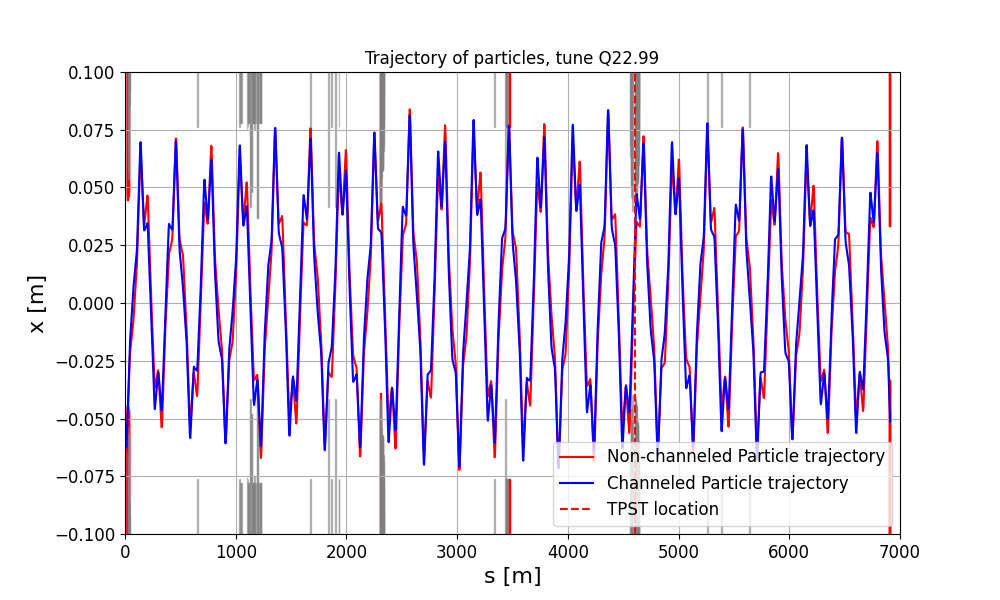

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import xtrack as xt

#line.insert_element("TECS.everest_crystal", TECS, at_s=line.get_table()['s', 'tecs.21602'])
#line.build_tracker()

# Initialize a single particle at TECA location
particlesNONCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesNONCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordNONCH = line.record_last_track

# Initialize a single particle at TECA location
particlesCH = line.build_particles(
    method='4d',
    x=TECA.jaw,
    px=TECA.tilt + TECA.bending_angle,  # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
    y=0,
    py=0,
    zeta=0,
    delta=deltaP_P,
    mass0=xt.PROTON_MASS_EV,
    p0c=400e9
)

# Track particles for N turns and store positions
line.track(particlesCH, num_turns=1, turn_by_turn_monitor="ONE_TURN_EBE",)
recordCH = line.record_last_track

# Check if the particle is lost during the tracking
if np.any(particles.state < 1):
    lost_turn = np.where(particles.state < 1)[0][0]
    lost_element_index = particles.at_element[lost_turn]
    lost_element_name = line.element_names[lost_element_index]
    print(f"Particle lost at element {lost_element_name} (index {lost_element_index}) on turn {lost_turn}")
        
else:
    print("Particle not lost during the tracking")

# Plot the phase space at TECA location
plt.figure(figsize=(10, 6))
plt.plot(recordNONCH.s[0], recordNONCH.x[0], '-',color = 'red', label='Non-channeled Particle trajectory')
plt.plot(recordCH.s[0], recordCH.x[0], '-',color = 'blue', label='Channeled Particle trajectory')
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title(f'Trajectory of particles, tune Q{tune}')
plt.grid(True)

plt.ylim(-0.1, 0.1)
plt.xlim(0, 7000)

# Insert rectangles for each element in df_elements
for _, row in df_elements.iterrows():
    color = 'grey'
    alpha = 0.5
    if row['Element Name'] in [elem[0] for elem in blocking_elements]:
        plt.gca().add_patch(rect_min)
        color = 'red'
        alpha = 1.0
    # Rectangle from max_x to top
    # Rectangle from bottom to min_x['Position'], row['max_x']), width=10, height=0.25 - row['max_x'], color='grey', alpha=0.5)
    rect_min = plt.Rectangle((row['Position'], -0.25), width=8, height=row['min_x'] + 0.25, color=color, alpha=alpha)
    plt.gca().add_patch(rect_min)
    
    # Rectangle from max_x to top
    rect_max = plt.Rectangle((row['Position'], row['max_x']), width=8, height=0.25 - row['max_x'], color=color, alpha=alpha)
    plt.gca().add_patch(rect_max)
plt.axvline(x=tpst_position, color='r', linestyle='--', label='TPST location')
#plt.axvline(x=tecs_position, color='r', linestyle='--', label='TECS location')

plt.legend()
plt.show()